In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

# 簡易計算と詳細計算の比較
## 詳細計算の結果を読み込む

In [2]:
# CSVファイルを読み込む
df = pd.read_csv('wall_status_data_frame_detailed.csv', index_col=0)

# 収束しなかった場合のデータを削除する
df = df.query("is_optimize_succeed == True")

# 分析用にメッセージ列を削除
df = df.drop(["is_optimize_succeed", "optimize_message"], axis=1)

# 1つでも欠損値NaNがある行を削除する
df = df[~np.isnan(df).any(axis=1)]

# 冬期条件、夏期条件の計算結果を抽出
df_detailed = pd.concat([df.query("theta_e <= 10.0 & theta_r == 20.0"), df.query("theta_e >= 25.0 & theta_r == 27.0")])
df_detailed

,theta_e,theta_r,j_surf,a_surf,C_1,C_2,l_h,l_w,l_d,angle,...,h_cv,h_rv,theta_as_e,k_e,q_room_side,heat_balance_0,heat_balance_1,heat_balance_2,heat_balance_3,heat_balance_4
0,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,...,2.825350,0.434728,-4.623813,0.820794,-2.363617,0.000000e+00,2.220446e-15,-1.776357e-15,2.842171e-14,-2.220446e-16
1,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,...,2.488053,2.077843,-4.887580,0.829586,-2.409223,0.000000e+00,3.552714e-15,3.552714e-15,0.000000e+00,-4.440892e-16
2,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,...,2.281691,3.586179,-4.949801,0.831660,-2.426662,-2.842171e-14,3.552714e-15,-7.105427e-15,-2.842171e-14,-4.440892e-16
3,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,...,4.362720,0.410906,-9.856252,0.995208,-2.892881,2.842171e-14,8.881784e-15,0.000000e+00,0.000000e+00,0.000000e+00
4,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,...,4.109646,1.968272,-9.814749,0.993825,-2.901498,-2.842171e-14,-3.552714e-15,-7.105427e-15,0.000000e+00,-8.881784e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708583,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,...,5.692031,3.780112,50.470072,0.488960,56.325852,0.000000e+00,-4.547474e-13,-1.136868e-13,8.526513e-14,0.000000e+00
708584,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,...,5.396892,6.610045,53.646967,0.555145,67.563938,-1.818989e-12,-2.842171e-13,-2.273737e-13,2.842171e-14,0.000000e+00
708585,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,...,8.095389,0.760302,40.829960,0.288124,32.615303,-9.094947e-13,4.227729e-13,5.684342e-14,-2.842171e-14,-3.552714e-15
708586,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,...,7.711546,3.701609,46.506060,0.406376,48.920559,-9.094947e-13,1.023182e-12,2.273737e-13,-8.526513e-14,7.105427e-15


## 簡易計算の結果を読み込む

### 簡易計算法案③（通気層を有する壁体の修正熱貫流率、修正日射熱取得率、室内表面熱流を求める）の計算結果

In [5]:
# CSVファイルを読み込む
df = pd.read_csv('wall_status_data_frame_simplified_calculation_no03.csv', index_col=0)

# 1つでも欠損値NaNがある行を削除する
df = df[~np.isnan(df).any(axis=1)]

# 相当外気温度と室温が同じ値となるケースを除外
df = df.query("theta_sat != theta_r")

# 冬期条件、夏期条件の計算結果を抽出
df_simplified_no_03 = pd.concat([df.query("theta_e <= 10.0 & theta_r == 20.0"), df.query("theta_e >= 25.0 & theta_r == 27.0")])
df_simplified_no_03

,theta_e,theta_r,j_surf,a_surf,C_1,C_2,l_h,l_w,l_d,angle,v_a,l_s,emissivity_1,emissivity_2,theta_sat,h_cv,h_rv,u_dash,eta_dash,q_room_side
0,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,0.0,0.45,0.9,0.1,-10.0,2.3020,0.499846,0.078389,0.000000,-2.351676
1,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,0.0,0.45,0.9,0.5,-10.0,2.3020,2.394000,0.080430,0.000000,-2.412895
2,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,0.0,0.45,0.9,0.9,-10.0,2.3020,4.135091,0.081035,0.000000,-2.431062
3,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,0.5,0.45,0.9,0.1,-10.0,4.3405,0.499846,0.096452,0.000000,-2.893575
4,-10.0,20.0,0.0,0.0,0.5,0.1,3.0,0.05,0.05,0.0,0.5,0.45,0.9,0.5,-10.0,4.3405,2.394000,0.096845,0.000000,-2.905352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708583,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,0.5,0.45,0.9,0.5,75.0,3.9005,3.133421,2.106059,0.037112,53.960234
708584,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,0.5,0.45,0.9,0.9,75.0,3.9005,5.412273,2.265978,0.047881,66.008875
708585,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,1.0,0.45,0.9,0.1,75.0,5.9570,0.654231,2.095188,0.012745,29.506761
708586,35.0,27.0,1000.0,1.0,100.0,5.0,12.0,10.00,0.30,90.0,1.0,0.45,0.9,0.5,75.0,5.9570,3.133421,2.299462,0.029285,47.680521


## 作図用の関数を定義
### 推定値の確認用グラフ

In [7]:
def setPltComparison(fig_title:str, x_label:str, y_label:str, x_data:np.array, y_data:np.array,
                     xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float):
    
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    fig, ax = plt.subplots()

    # グラフタイトルを設定
    fig.suptitle(fig_title)
        
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
        
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
        
    # 描画データ設定
    x = x_data
    y = y_data
                
    # 散布図の描画設定
    ax.scatter(x, y, s=30, marker=".")

    # 線形グラフの描画設定    
    ax.plot([xlim_min, xlim_max], [ylim_min, ylim_max],color="black")
        
    # 軸の描画範囲設定
    #ax.set_xlim(xlim_min, xlim_max)
    #ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.show()

## 計算結果の比較

- Simplified Method #1 : 簡易版の行列式による計算結果
- Simplified Method #2 : 簡易式による計算結果（放射熱伝達率をゼロとした場合）
- Simplified Method #2rev : 簡易式による計算結果（通気層内の総合熱伝達を適用した場合）

### 室内表面熱流(q_room_side)の比較

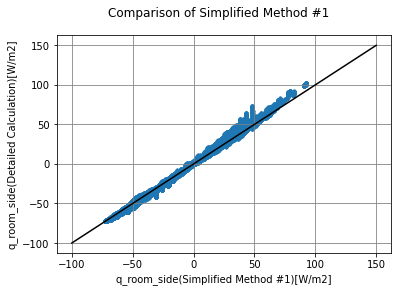

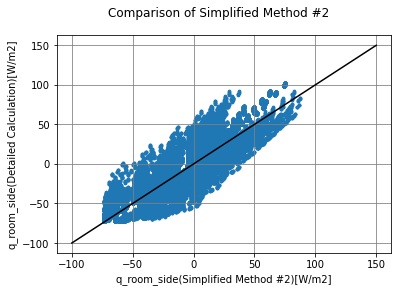

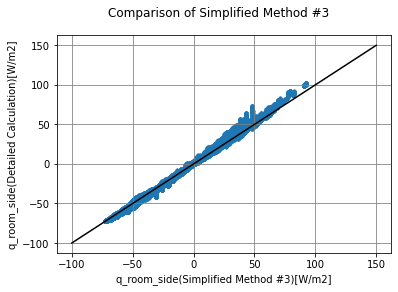

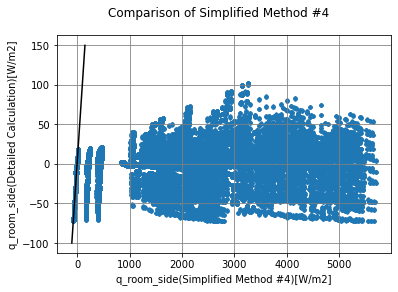

In [8]:
setPltComparison(
       fig_title = "Comparison of Simplified Method #3",
       x_label = "q_room_side(Simplified Method #3)[W/m2]",
       y_label = "q_room_side(Detailed Calculation)[W/m2]", 
       x_data = df_simplified_no_03["q_room_side"],
       y_data = df_detailed["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 150.0,
       ylim_min = -100.0,
       ylim_max = 150.0
      )

### 室内表面熱流(q_room_side)の比較：放射率別に描画

#### 簡易計算法③

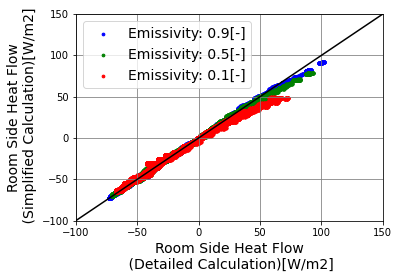

In [11]:
# グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
# グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
fig, ax = plt.subplots(figsize=(5.5, 3.8))

# グラフタイトルを設定
fig1.suptitle("Comparison of Simplified Method #3")
    
# 補助軸の設定
ax.grid(which='major', color='gray', linestyle='-')
ax.grid(which='minor', color='gray', linestyle='-')

# 軸ラベルの設定
ax.set_xlabel('Room Side Heat Flow\n (Detailed Calculation)[W/m2]', fontsize=14)
ax.set_ylabel('Room Side Heat Flow\n (Simplified Calculation)[W/m2]', fontsize=14)

# 散布図の描画設定
ax.scatter(df_detailed.query("emissivity_2 == 0.9")['q_room_side'], df_simplified_no_03.query("emissivity_2 == 0.9")['q_room_side'], color='b', label='Emissivity: 0.9[-]', s=30, marker=".")
ax.scatter(df_detailed.query("emissivity_2 == 0.5")['q_room_side'], df_simplified_no_03.query("emissivity_2 == 0.5")['q_room_side'], color='g', label='Emissivity: 0.5[-]', s=30, marker=".")
ax.scatter(df_detailed.query("emissivity_2 == 0.1")['q_room_side'], df_simplified_no_03.query("emissivity_2 == 0.1")['q_room_side'], color='r', label='Emissivity: 0.1[-]', s=30, marker=".")

# 線形グラフの描画設定    
ax.plot([-100.0, 150.0], [-100.0, 150.0],color="black")

# 軸の描画範囲設定
ax.set_xlim(-100.0, 150.0)
ax.set_ylim(-100.0, 150.0)
    
plt.legend(fontsize=14)
plt.show()

### 簡易計算法③の計算結果分析
#### 日射量=0の場合（風速別に描画）

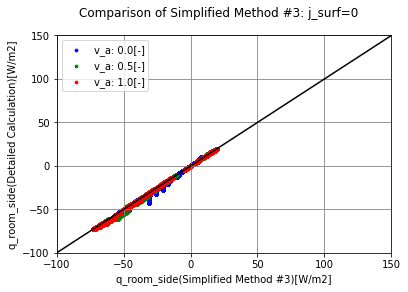

In [13]:
fig1 = plt.figure()
ax = fig1.add_subplot(1, 1, 1)

# グラフタイトルを設定
fig1.suptitle("Comparison of Simplified Method #3: j_surf=0")
    
# 補助軸の設定
ax.grid(which='major', color='gray', linestyle='-')
ax.grid(which='minor', color='gray', linestyle='-')

# 軸ラベルの設定
ax.set_xlabel('q_room_side(Simplified Method #3)[W/m2]')
ax.set_ylabel('q_room_side(Detailed Calculation)[W/m2]')

# 散布図の描画設定
df_simple = df_simplified_no_03.query("j_surf == 0.0")
df_detail = df_detailed.query("j_surf == 0.0")

ax.scatter(df_simple.query("v_a == 0.0")['q_room_side'], df_detail.query("v_a == 0.0")['q_room_side'], color='b', label='v_a: 0.0[-]', s=30, marker=".")
ax.scatter(df_simple.query("v_a == 0.5")['q_room_side'], df_detail.query("v_a == 0.5")['q_room_side'], color='g', label='v_a: 0.5[-]', s=30, marker=".")
ax.scatter(df_simple.query("v_a == 1.0")['q_room_side'], df_detail.query("v_a == 1.0")['q_room_side'], color='r', label='v_a: 1.0[-]', s=30, marker=".")

# 線形グラフの描画設定    
ax.plot([-100.0, 150.0], [-100.0, 150.0],color="black")

# 軸の描画範囲設定
ax.set_xlim(-100.0, 150.0)
ax.set_ylim(-100.0, 150.0)
    
plt.legend()
plt.show()

## 現行省エネルギー基準による室内表面熱流の計算

In [14]:
def getHeatFlowbyCurrentSandardMethod(theta_e: float, theta_r: float, j_surf: float, a_surf:float, c_2:float):

    # 計算条件を設定
    h_o = 25.0

    # 各部位の熱抵抗を設定
    R_se = 0.11 # 熱的境界外側の表面熱伝達抵抗（通気層等の場合）, m2K/W
    R_si = 0.11 # 熱的境界内側の表面熱伝達抵抗, m2K/W
    R_k = 1.0 / c_2   # 断熱層の熱抵抗, m2K/W

    # U値を計算
    U_k = 1.0 / (R_se + R_si + R_k)
    
    # η値を計算
    eta_k = 0.034 * U_k

    # 相当外気温度を計算
    theta_sat = theta_e + (a_surf * j_surf) / h_o

    # 室内表面熱流を計算
    q_k = U_k * (theta_sat - theta_r)

    return U_k, eta_k, theta_sat, q_k


### 室内表面熱流の試算

In [15]:
# 夏期条件
U_k, eta_k, theta_sat, q_k = getHeatFlowbyCurrentSandardMethod(theta_e=35.0, theta_r=27.0,
                                                        j_surf=1000.0, a_surf=0.5, c_2=0.55)
print('U_k = ' + str(U_k) + '\neta_k = ' + str(eta_k) + '\nq_k = ' + str(q_k))

U_k = 0.4906333630686887
eta_k = 0.016681534344335416
q_k = 13.737734165923284


In [16]:
# 冬期条件
U_k, eta_k, theta_sat, q_k = getHeatFlowbyCurrentSandardMethod(theta_e=-10.0, theta_r=20.0,
                                                        j_surf=1000.0, a_surf=0.5, c_2=2.55)
print('U_k = ' + str(U_k) + '\neta_k = ' + str(eta_k)  + '\nq_k = ' + str(q_k))

U_k = 1.6335682254964765
eta_k = 0.0555413196668802
q_k = -16.335682254964766
